In [1]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
data = pd.read_csv(r"C:\Users\Viplav Gupta\OneDrive\Desktop\Data Science Projects\EkamDor\New Version\Merged CSV\processed_posts.csv")

In [4]:
print(data.shape)
print(data.columns.tolist())

(3754, 10)
['type', 'url', 'caption', 'hashtags', 'mentions', 'timestamp', 'location', 'post_id', 'clean_caption_english', 'clean_hashtags_english']


In [5]:
data["content_text"] = (
    data["clean_caption_english"].fillna("") + " " +
    data["clean_hashtags_english"].fillna("")
).str.strip()

In [8]:
data.columns.tolist()

['type',
 'url',
 'caption',
 'hashtags',
 'mentions',
 'timestamp',
 'location',
 'post_id',
 'clean_caption_english',
 'clean_hashtags_english',
 'content_text']

In [6]:
print(
    data[
        [
            "post_id",
            "clean_caption_english",
            "clean_hashtags_english",
            "content_text"
        ]
    ].head(10).to_string(index=False)
)

   post_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       clean_caption_english                                                                                                                                          clean_hashtags_english                                                                                                  

In [7]:
empty_content = data[
    data["content_text"].str.strip() == ""
]

print("Empty posts:", len(empty_content))

Empty posts: 204


In [9]:
user_football_shayudh = """
Football, soccer, Lionel Messi, World Cup,
football highlights, international football
"""

user_tech_ayush = """
Artificial intelligence, AI, ChatGPT,
technology, smartphones, laptops, programming
"""

user_fashion_abhishek = """
Men's fashion, men's clothing, outfits,
menswear, styling, fashion trends
"""

user_food_namita = """
Cooking, food recipes, momo, homemade food,
easy recipes, delicious food
"""

user_cricket_amit = """
Cricket, IPL, Team India, Virat Kohli,
T20 cricket, cricket highlights
"""

dummy_user_viplav = """
I am interested in cricket, IPL, Team India,
Virat Kohli, cricket highlights and T20 cricket.
"""

In [11]:
dummy_users = {
    "shayudh_football": user_football_shayudh,
    "ayush_technology": user_tech_ayush,
    "abhishek_fashion": user_fashion_abhishek,
    "namita_food": user_food_namita,
    "amit_cricket": user_cricket_amit,
    "viplav_cricket": dummy_user_viplav
}

In [12]:
dummy_users

{'shayudh_football': '\nFootball, soccer, Lionel Messi, World Cup,\nfootball highlights, international football\n',
 'ayush_technology': '\nArtificial intelligence, AI, ChatGPT,\ntechnology, smartphones, laptops, programming\n',
 'abhishek_fashion': "\nMen's fashion, men's clothing, outfits,\nmenswear, styling, fashion trends\n",
 'namita_food': '\nCooking, food recipes, momo, homemade food,\neasy recipes, delicious food\n',
 'amit_cricket': '\nCricket, IPL, Team India, Virat Kohli,\nT20 cricket, cricket highlights\n',
 'viplav_cricket': '\nI am interested in cricket, IPL, Team India,\nVirat Kohli, cricket highlights and T20 cricket.\n'}

In [13]:
def recommend_posts(
    user_text,
    embedding_model,
    post_embeddings,
    data,
    top_k=10
):
    user_embedding = embedding_model.encode(
        user_text,
        normalize_embeddings=True
    )

    similarity_scores = cosine_similarity(
        [user_embedding],
        post_embeddings
    )[0]

    top_indices = np.argsort(
        similarity_scores
    )[::-1][:top_k]

    results = data.iloc[top_indices].copy()

    results["similarity"] = similarity_scores[top_indices]

    return results

Model 1: MiniLM

In [22]:
model_minilm = SentenceTransformer("all-MiniLM-L6-v2")

embeddings_minilm = model_minilm.encode(
    data["content_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("MiniLM embedding shape:", embeddings_minilm.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

MiniLM embedding shape: (3754, 384)


In [23]:
viplav_profile = dummy_users["viplav_cricket"]

viplav_embedding = model_minilm.encode(
    viplav_profile,
    normalize_embeddings=True
)

similarity_scores = cosine_similarity(
    [viplav_embedding],
    embeddings_minilm
)[0]

top_k = 10
top_indices = np.argsort(similarity_scores)[::-1][:top_k]

minilm_viplav_results = data.iloc[top_indices].copy()
minilm_viplav_results["similarity"] = similarity_scores[top_indices]

minilm_viplav_results[
    ["post_id", "clean_caption_english", "clean_hashtags_english", "similarity"]
]

,post_id,clean_caption_english,clean_hashtags_english,similarity
918,POST_00919,"cricketnextofficial on August 4, 2026: "" 2013 ...",#viratkohli #GautamGambhir #ipl #anilchoudhary...,0.565817
821,POST_00822,"icchindiofficial on June 28, 2026: "" T20 2026 ...",#T20WorldCup #cricket #cricketreels,0.522673
1037,POST_01038,"azmi cricketacademy on August 3, 2026: ""Open n...",#cricketreels #trending #cricket #explore #exp...,0.498861
3328,POST_03649,"jayshah220988 on July 30, 2026: ""It s exciting...",#CWC27,0.491258
3549,POST_03919,"anantyagi on August 5, 2026: ""Thank you A mad ...",NaN,0.482031
5,POST_00006,"ai.with.naveen on August 10, 2026: "" DSP Moham...",#MohammedSiraj #DevduttPadikkal #SarfarazKhan ...,0.479387
1304,POST_01305,"cricketcomau on July 23, 2026: ""Teenager Vaibh...",NaN,0.472618
3402,POST_03772,"cricinlast24hr on July 26, 2026: "" VIRAT KOHLI...",NaN,0.463300
793,POST_00794,"abhiishekcore on July 15, 2026: ""every younger...",#abhisheksharma #cricket #indiancricketteam,0.453226
139,POST_00140,"cricketnextofficial on August 10, 2026: ""Yasha...",#AjinkyaRahane #YashasviJaiswal #DuleepTrophy ...,0.450257


In [24]:
def recommend_posts(user_profile, model, post_embeddings, data, top_k=10):
    user_embedding = model.encode(
        user_profile,
        normalize_embeddings=True
    )

    similarity_scores = cosine_similarity(
        [user_embedding],
        post_embeddings
    )[0]

    top_indices = np.argsort(similarity_scores)[::-1][:top_k]

    results = data.iloc[top_indices].copy()
    results["similarity"] = similarity_scores[top_indices]

    return results

In [25]:
minilm_test = recommend_posts(
    dummy_users["viplav_cricket"],
    model_minilm,
    embeddings_minilm,
    data,
    top_k=10
)

minilm_test[
    ["post_id", "clean_caption_english", "similarity"]
]

,post_id,clean_caption_english,similarity
918,POST_00919,"cricketnextofficial on August 4, 2026: "" 2013 ...",0.565817
821,POST_00822,"icchindiofficial on June 28, 2026: "" T20 2026 ...",0.522673
1037,POST_01038,"azmi cricketacademy on August 3, 2026: ""Open n...",0.498861
3328,POST_03649,"jayshah220988 on July 30, 2026: ""It s exciting...",0.491258
3549,POST_03919,"anantyagi on August 5, 2026: ""Thank you A mad ...",0.482031
5,POST_00006,"ai.with.naveen on August 10, 2026: "" DSP Moham...",0.479387
1304,POST_01305,"cricketcomau on July 23, 2026: ""Teenager Vaibh...",0.472618
3402,POST_03772,"cricinlast24hr on July 26, 2026: "" VIRAT KOHLI...",0.463300
793,POST_00794,"abhiishekcore on July 15, 2026: ""every younger...",0.453226
139,POST_00140,"cricketnextofficial on August 10, 2026: ""Yasha...",0.450257


In [26]:
results_minilm = {}

for user_name, user_profile in dummy_users.items():
    results_minilm[user_name] = recommend_posts(
        user_profile,
        model_minilm,
        embeddings_minilm,
        data,
        top_k=10
    )

In [27]:
results_minilm["amit_cricket"][
    ["post_id", "clean_caption_english", "similarity"]
]

,post_id,clean_caption_english,similarity
918,POST_00919,"cricketnextofficial on August 4, 2026: "" 2013 ...",0.660966
3549,POST_03919,"anantyagi on August 5, 2026: ""Thank you A mad ...",0.589640
3402,POST_03772,"cricinlast24hr on July 26, 2026: "" VIRAT KOHLI...",0.588301
821,POST_00822,"icchindiofficial on June 28, 2026: "" T20 2026 ...",0.570589
139,POST_00140,"cricketnextofficial on August 10, 2026: ""Yasha...",0.557611
5,POST_00006,"ai.with.naveen on August 10, 2026: "" DSP Moham...",0.552533
3328,POST_03649,"jayshah220988 on July 30, 2026: ""It s exciting...",0.552508
793,POST_00794,"abhiishekcore on July 15, 2026: ""every younger...",0.545663
2092,POST_02112,NaN,0.535083
2680,POST_02982,"starsportskan on May 31, 2026: "" - Virat Kohli...",0.533828


Model 2: BGE-Small

In [28]:
model_bge_small = SentenceTransformer("BAAI/bge-small-en-v1.5")

embeddings_bge_small = model_bge_small.encode(
    data["content_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("BGE-Small embedding shape:", embeddings_bge_small.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

BGE-Small embedding shape: (3754, 384)


In [29]:
results_bge_small = {}

for user_name, user_profile in dummy_users.items():
    results_bge_small[user_name] = recommend_posts(
        user_profile,
        model_bge_small,
        embeddings_bge_small,
        data,
        top_k=10
    )

In [30]:
results_bge_small["amit_cricket"][
    ["post_id", "clean_caption_english", "similarity"]
]

,post_id,clean_caption_english,similarity
1770,POST_01790,"step.up.cricket on July 23, 2026: "" While mode...",0.778309
3549,POST_03919,"anantyagi on August 5, 2026: ""Thank you A mad ...",0.755980
1085,POST_01086,"indiancricketteam on July 23, 2026: "" Toss and...",0.751941
3402,POST_03772,"cricinlast24hr on July 26, 2026: "" VIRAT KOHLI...",0.749698
793,POST_00794,"abhiishekcore on July 15, 2026: ""every younger...",0.744310
1394,POST_01395,"circleofcricket on July 27, 2026: ""Reward for ...",0.740466
2680,POST_02982,"starsportskan on May 31, 2026: "" - Virat Kohli...",0.738431
1225,POST_01226,"spor.tsvideos45 on July 4, 2026: ""This Instagr...",0.734672
800,POST_00801,"ai.with.naveen on June 25, 2026: ""Virat Kohli-...",0.731597
1215,POST_01216,"cricket live 247 on August 4, 2026: ""Many peop...",0.728067


Model 3: BGE-Base

In [31]:
model_bge_base = SentenceTransformer("BAAI/bge-base-en-v1.5")

embeddings_bge_base = model_bge_base.encode(
    data["content_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("BGE-Base embedding shape:", embeddings_bge_base.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Viplav Gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Viplav Gupta\.cache\huggingface\hub\models--BAAI--bge-base-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

BGE-Base embedding shape: (3754, 768)


In [33]:
results_bge_base = {}

for user_name, user_profile in dummy_users.items():
    results_bge_base[user_name] = recommend_posts(
        user_profile,
        model_bge_base,
        embeddings_bge_base,
        data,
        top_k=10
    )

Model 4: Multilingual-E5

In [35]:
model_e5 = SentenceTransformer("intfloat/multilingual-e5-base")

embeddings_e5 = model_e5.encode(
    data["content_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("E5 embedding shape:", embeddings_e5.shape)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

C:\Users\Viplav Gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Viplav Gupta\.cache\huggingface\hub\models--intfloat--multilingual-e5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/118 [00:00<?, ?it/s]

E5 embedding shape: (3754, 768)


In [36]:
results_e5 = {}

for user_name, user_profile in dummy_users.items():
    results_e5[user_name] = recommend_posts(
        user_profile,
        model_e5,
        embeddings_e5,
        data,
        top_k=10
    )

Combine the Top-10 recommendations from all four models into one comparison table.

In [37]:
comparison_rows = []

for user_name in dummy_users.keys():
    for rank in range(10):
        comparison_rows.append({
            "user": user_name,
            "rank": rank + 1,
            "MiniLM_post": results_minilm[user_name].iloc[rank]["post_id"],
            "MiniLM_score": results_minilm[user_name].iloc[rank]["similarity"],
            "BGE_Small_post": results_bge_small[user_name].iloc[rank]["post_id"],
            "BGE_Small_score": results_bge_small[user_name].iloc[rank]["similarity"],
            "BGE_Base_post": results_bge_base[user_name].iloc[rank]["post_id"],
            "BGE_Base_score": results_bge_base[user_name].iloc[rank]["similarity"],
            "E5_post": results_e5[user_name].iloc[rank]["post_id"],
            "E5_score": results_e5[user_name].iloc[rank]["similarity"]
        })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,user,rank,MiniLM_post,MiniLM_score,BGE_Small_post,BGE_Small_score,BGE_Base_post,BGE_Base_score,E5_post,E5_score
0,shayudh_football,1,POST_03867,0.433842,POST_03867,0.753932,POST_03867,0.741600,POST_03837,0.840921
1,shayudh_football,2,POST_00488,0.430559,POST_01048,0.732553,POST_03837,0.689638,POST_03530,0.839027
2,shayudh_football,3,POST_03904,0.415268,POST_03798,0.720903,POST_01852,0.681666,POST_03867,0.837693
3,shayudh_football,4,POST_02100,0.401331,POST_03837,0.718114,POST_00488,0.680477,POST_00488,0.837686
4,shayudh_football,5,POST_01048,0.381782,POST_03904,0.710359,POST_01048,0.676034,POST_02112,0.836400
5,shayudh_football,6,POST_03919,0.377672,POST_03557,0.709535,POST_03022,0.672465,POST_00497,0.831333
6,shayudh_football,7,POST_03530,0.374583,POST_00497,0.692080,POST_02112,0.659170,POST_03557,0.830934
7,shayudh_football,8,POST_03646,0.372930,POST_03813,0.685019,POST_03646,0.651839,POST_03798,0.830300
8,shayudh_football,9,POST_01852,0.368307,POST_03597,0.679941,POST_00497,0.647638,POST_04056,0.829765
9,shayudh_football,10,POST_00497,0.365211,POST_03586,0.679735,POST_03463,0.646590,POST_03904,0.828025


In [38]:
comparison_df.to_csv(
    "embedding_model_comparison.csv",
    index=False
)

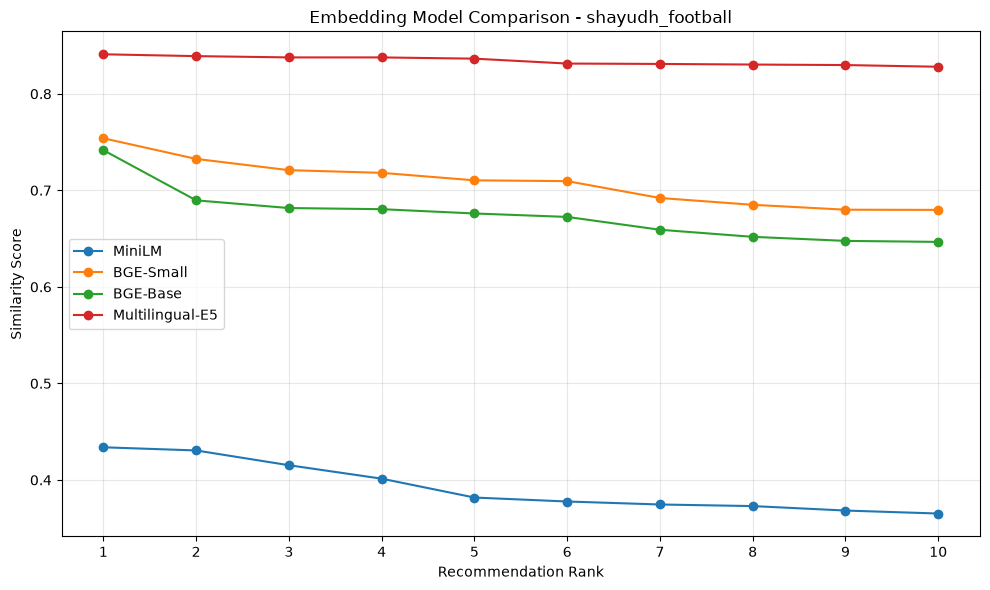

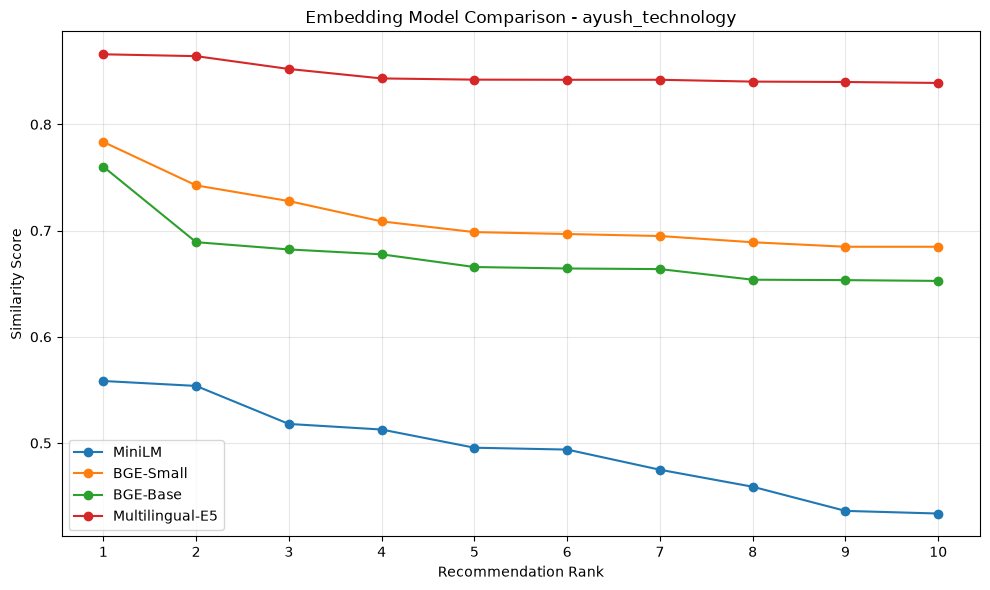

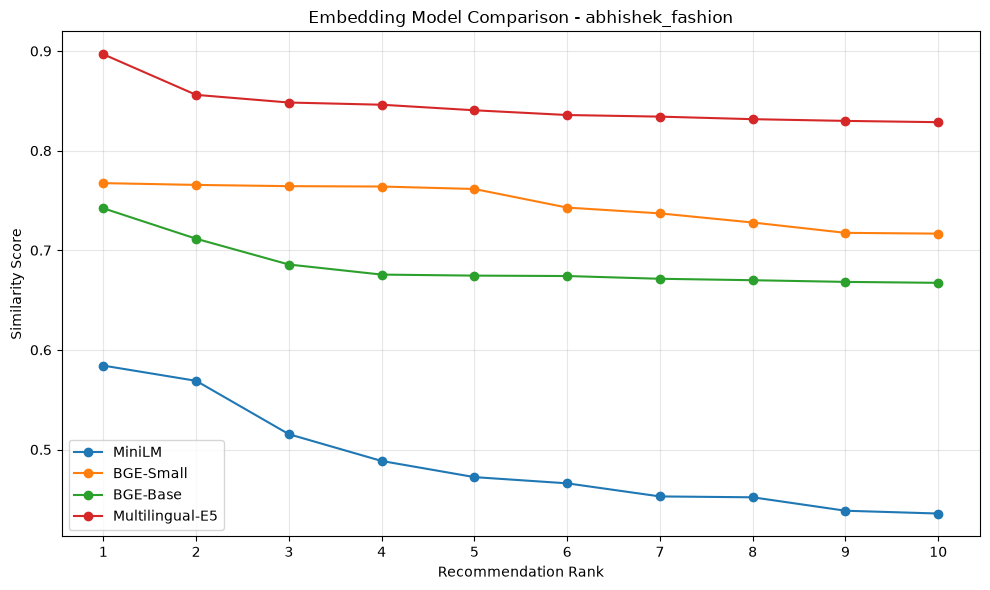

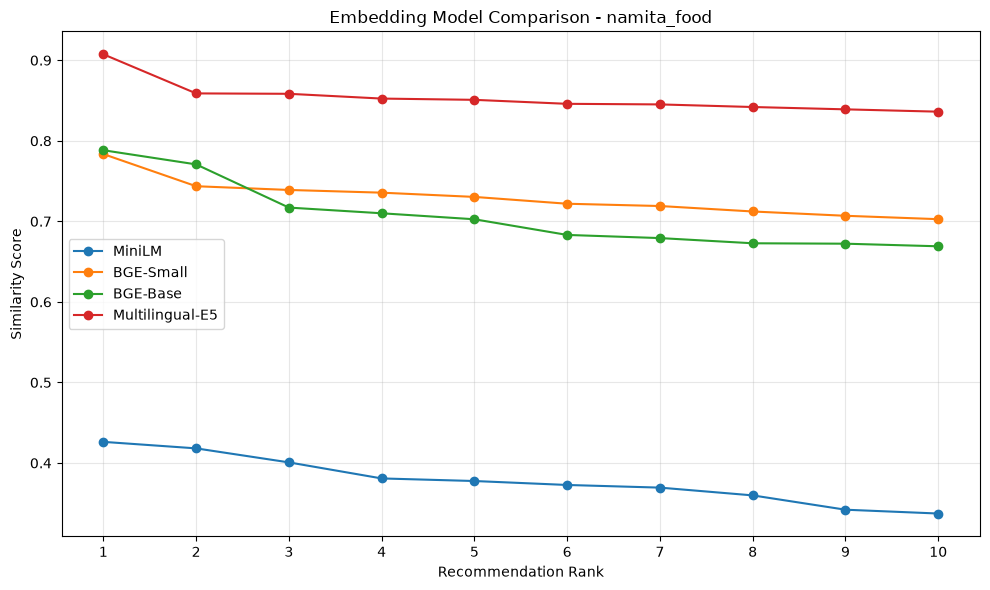

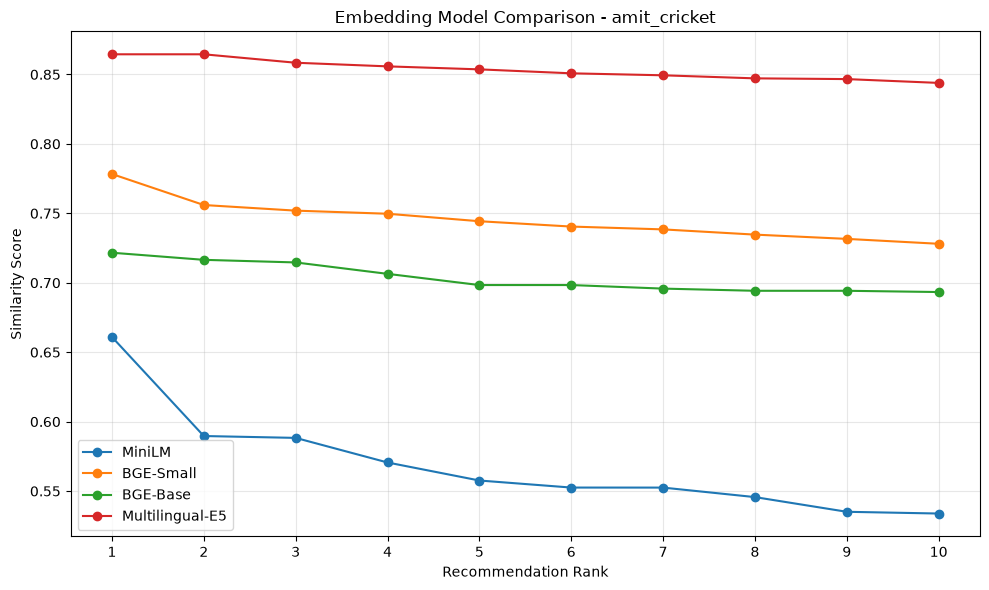

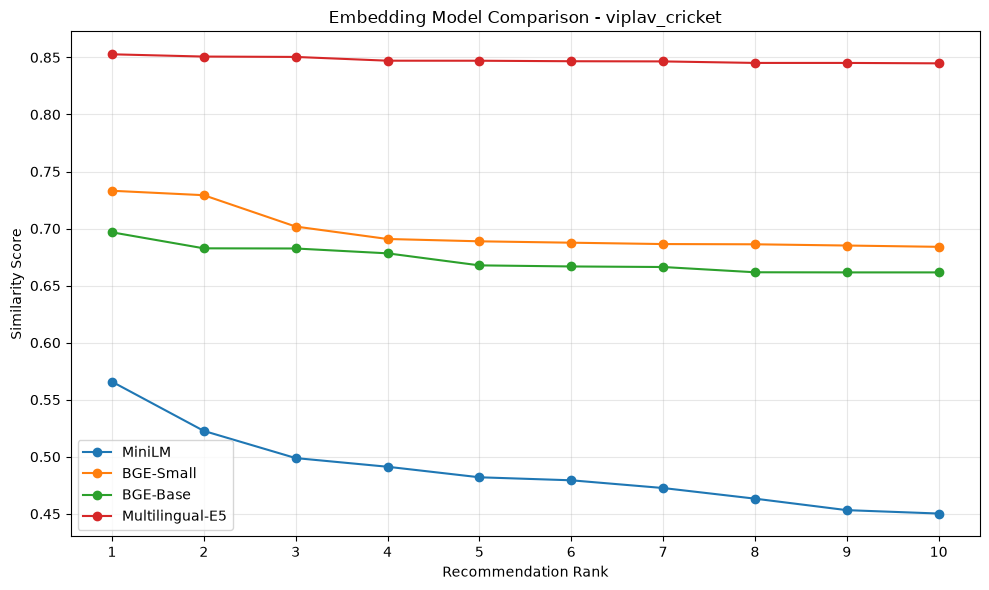

In [39]:
import matplotlib.pyplot as plt

for user_name in dummy_users.keys():
    plt.figure(figsize=(10, 6))

    plt.plot(
        range(1, 11),
        results_minilm[user_name]["similarity"].values,
        marker="o",
        label="MiniLM"
    )

    plt.plot(
        range(1, 11),
        results_bge_small[user_name]["similarity"].values,
        marker="o",
        label="BGE-Small"
    )

    plt.plot(
        range(1, 11),
        results_bge_base[user_name]["similarity"].values,
        marker="o",
        label="BGE-Base"
    )

    plt.plot(
        range(1, 11),
        results_e5[user_name]["similarity"].values,
        marker="o",
        label="Multilingual-E5"
    )

    plt.title(f"Embedding Model Comparison - {user_name}")
    plt.xlabel("Recommendation Rank")
    plt.ylabel("Similarity Score")
    plt.xticks(range(1, 11))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [42]:
plot_rows = []

for user_name in dummy_users.keys():
    for rank in range(10):
        plot_rows.extend([
            {
                "user": user_name,
                "rank": rank + 1,
                "model": "MiniLM",
                "similarity": results_minilm[user_name].iloc[rank]["similarity"]
            },
            {
                "user": user_name,
                "rank": rank + 1,
                "model": "BGE-Small",
                "similarity": results_bge_small[user_name].iloc[rank]["similarity"]
            },
            {
                "user": user_name,
                "rank": rank + 1,
                "model": "BGE-Base",
                "similarity": results_bge_base[user_name].iloc[rank]["similarity"]
            },
            {
                "user": user_name,
                "rank": rank + 1,
                "model": "E5",
                "similarity": results_e5[user_name].iloc[rank]["similarity"]
            }
        ])

plot_df = pd.DataFrame(plot_rows)

print(plot_df.shape)
plot_df.head()

(240, 4)


,user,rank,model,similarity
0,shayudh_football,1,MiniLM,0.433842
1,shayudh_football,1,BGE-Small,0.753932
2,shayudh_football,1,BGE-Base,0.741600
3,shayudh_football,1,E5,0.840921
4,shayudh_football,2,MiniLM,0.430559


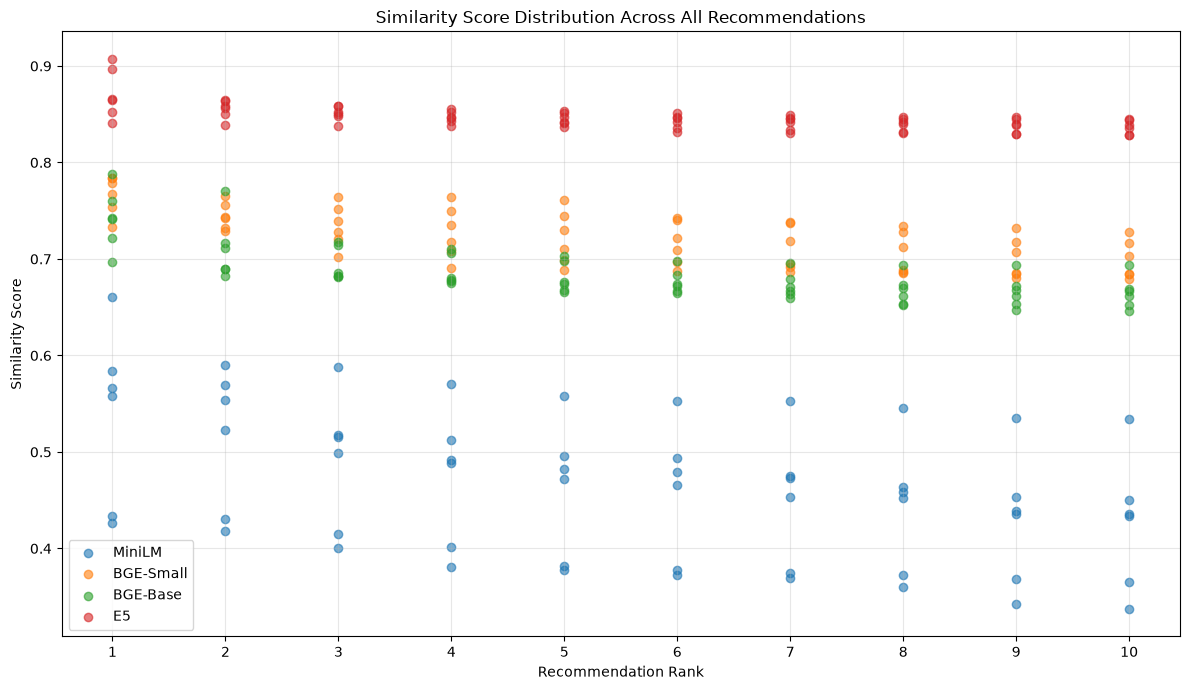

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for model in ["MiniLM", "BGE-Small", "BGE-Base", "E5"]:
    model_data = plot_df[plot_df["model"] == model]

    plt.scatter(
        model_data["rank"],
        model_data["similarity"],
        alpha=0.6,
        label=model
    )

plt.title("Similarity Score Distribution Across All Recommendations")
plt.xlabel("Recommendation Rank")
plt.ylabel("Similarity Score")
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
score_rows = []

for model_name, results in {
    "MiniLM": results_minilm,
    "BGE-Small": results_bge_small,
    "BGE-Base": results_bge_base,
    "E5": results_e5
}.items():
    for user_name in dummy_users.keys():
        scores = results[user_name]["similarity"].head(10)

        score_rows.append({
            "model": model_name,
            "user": user_name,
            "average_top10_similarity": scores.mean(),
            "top1_similarity": scores.iloc[0],
            "top10_similarity": scores.iloc[-1]
        })

score_df = pd.DataFrame(score_rows)

score_df

,model,user,average_top10_similarity,top1_similarity,top10_similarity
0,MiniLM,shayudh_football,0.392149,0.433842,0.365211
1,MiniLM,ayush_technology,0.493593,0.558418,0.433655
2,MiniLM,abhishek_fashion,0.487463,0.584239,0.435734
3,MiniLM,namita_food,0.378482,0.426242,0.337254
4,MiniLM,amit_cricket,0.568672,0.660966,0.533828
5,MiniLM,viplav_cricket,0.487943,0.565817,0.450257
6,BGE-Small,shayudh_football,0.708217,0.753932,0.679735
7,BGE-Small,ayush_technology,0.711123,0.783434,0.684778
8,BGE-Small,abhishek_fashion,0.746481,0.767412,0.716703
9,BGE-Small,namita_food,0.729498,0.783533,0.702719


<Axes: title={'center': 'Average Top-10 Similarity Score by Embedding Model'}, xlabel='Average Similarity Score', ylabel='Embedding Model'>

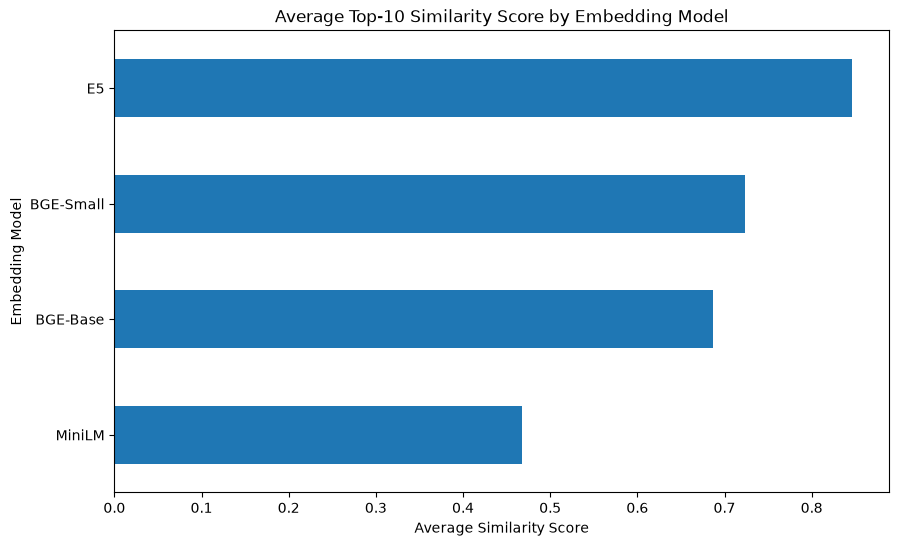

In [49]:
model_avg_scores = (
    score_df
    .groupby("model")["average_top10_similarity"]
    .mean()
    .sort_values(ascending=True)
)

model_avg_scores.plot(
    kind="barh",
    figsize=(10, 6),
    title="Average Top-10 Similarity Score by Embedding Model",
    xlabel="Average Similarity Score",
    ylabel="Embedding Model"
)

In [50]:
print(model_avg_scores)

model
MiniLM       0.468050
BGE-Base     0.686253
BGE-Small    0.722999
E5           0.846800
Name: average_top10_similarity, dtype: float32
